In [1]:
import json
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymutspec.annotation import rev_comp
from pymutspec.constants import possible_sbs192, possible_codons
from pymutspec.draw import plot_mutspec192
import SigProfilerAssignment
from scipy.stats import spearmanr

from utils import sbs2effect, collapse_sbs192, complete_sbs_columns

sns.set_style()
%matplotlib inline

In [2]:
# version of SigProfilerAssignment
SigProfilerAssignment.__version__

'0.1.7'

In [3]:
# funcs for specific data processing and writing


def read_human_triplet_counts(include_lower_nucls=False):
    with open("./data/triplet_counts_GRCh37.json") as fin:
        _human_counts_raw = json.load(fin)
        if include_lower_nucls:
            human_counts = defaultdict(int)
            for triplet, n in _human_counts_raw.items():
                human_counts[triplet.upper()] += n
            human_counts = dict(human_counts)        
        else:
            # without aAa, tAA, tgc etc. Only upper case
            _human_counts_raw = {x: _human_counts_raw[x] for x in possible_codons}
            human_counts = defaultdict(int)
            for triplet, n in _human_counts_raw.items():
                human_counts[triplet.upper()] += n
            human_counts = dict(human_counts)
        return human_counts


def save_wide_cls_spectra(df: pd.DataFrame, filename=None, human_counts: dict={}, scale_coef=6.6e-5):
    assert df.shape[1] == 96
    df.columns.name = "MutationType"
    multiplier = df.columns.to_series().apply(lambda x: x[0] + x[2] + x[-1]).map(human_counts)
    rescaled = (df * multiplier * scale_coef).T
    rescaled = rescaled.round().astype(int)
    if filename is not None:
        rescaled.sort_index().to_csv(filename, sep="\t")
    return rescaled

In [4]:
possible_sbs6 = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
possible_sbs96 = [x for x in possible_sbs192 if x[2:5] in possible_sbs6]
print(possible_sbs96)

['A[C>A]A', 'A[C>A]C', 'A[C>A]G', 'A[C>A]T', 'C[C>A]A', 'C[C>A]C', 'C[C>A]G', 'C[C>A]T', 'G[C>A]A', 'G[C>A]C', 'G[C>A]G', 'G[C>A]T', 'T[C>A]A', 'T[C>A]C', 'T[C>A]G', 'T[C>A]T', 'A[C>G]A', 'A[C>G]C', 'A[C>G]G', 'A[C>G]T', 'C[C>G]A', 'C[C>G]C', 'C[C>G]G', 'C[C>G]T', 'G[C>G]A', 'G[C>G]C', 'G[C>G]G', 'G[C>G]T', 'T[C>G]A', 'T[C>G]C', 'T[C>G]G', 'T[C>G]T', 'A[C>T]A', 'A[C>T]C', 'A[C>T]G', 'A[C>T]T', 'C[C>T]A', 'C[C>T]C', 'C[C>T]G', 'C[C>T]T', 'G[C>T]A', 'G[C>T]C', 'G[C>T]G', 'G[C>T]T', 'T[C>T]A', 'T[C>T]C', 'T[C>T]G', 'T[C>T]T', 'A[T>A]A', 'A[T>A]C', 'A[T>A]G', 'A[T>A]T', 'C[T>A]A', 'C[T>A]C', 'C[T>A]G', 'C[T>A]T', 'G[T>A]A', 'G[T>A]C', 'G[T>A]G', 'G[T>A]T', 'T[T>A]A', 'T[T>A]C', 'T[T>A]G', 'T[T>A]T', 'A[T>C]A', 'A[T>C]C', 'A[T>C]G', 'A[T>C]T', 'C[T>C]A', 'C[T>C]C', 'C[T>C]G', 'C[T>C]T', 'G[T>C]A', 'G[T>C]C', 'G[T>C]G', 'G[T>C]T', 'T[T>C]A', 'T[T>C]C', 'T[T>C]G', 'T[T>C]T', 'A[T>G]A', 'A[T>G]C', 'A[T>G]G', 'A[T>G]T', 'C[T>G]A', 'C[T>G]C', 'C[T>G]G', 'C[T>G]T', 'G[T>G]A', 'G[T>G]C', 'G[T>G]G'

## Load and Explore human trinucl counts for renormalization (emulation of human spectra for COSMIC decomposition) 

In [5]:
# read human genome trinucleotide counts
human_counts = read_human_triplet_counts()
human_counts_wl = read_human_triplet_counts(True)

In [6]:
x = pd.Series(human_counts).sort_index().values
y = pd.Series(human_counts_wl).sort_index().values
print(spearmanr(x, y))
# plt.scatter(x, y)
# plt.show()

SignificanceResult(statistic=0.9725274725274725, pvalue=5.851608347350969e-41)


In [7]:
# check forvard and rev-comp triplets freqs
d = defaultdict(dict)
for triplet, n in human_counts_wl.items():
    if triplet[1] in "CT":
        # print(triplet, n)
        d[triplet]["cosmic"] = n
    else:
        d[rev_comp(triplet)]["other"] = n

d = pd.DataFrame(d).T
d["diff"] = d.cosmic - d.other
d["diff%"] = d["diff"] / d['cosmic']
d

,other,cosmic,diff,diff%
TTA,61780796,61863454,82658,0.001336
GTT,43438625,43597716,159091,0.003649
ACC,34933366,34902100,-31266,-0.000896
CCC,39705055,39661785,-43270,-0.001091
CCT,53346173,53384677,38504,0.000721
CTA,38490211,38440347,-49864,-0.001297
CCA,55455476,55332829,-122647,-0.002217
TTG,56465883,56667346,201463,0.003555
TTT,114318196,114683164,364968,0.003182
GTA,33829362,33842736,13374,0.000395


Forvard and rev-comp triplets freqs are almost equal, so we need to use triplets with C & T in 2nd position

## Need to generate many variants of 96-comp spectra:

- **low ts**: only transitions (Gh>Ah and Th>Ch)
- **low ts&tv**: transitions (Gh>Ah and Th>Ch) & averaged transversions [(h + l) / 2]
- **high ts**: only transitions (Ch>Th and Ah>Gh)
- **high ts&tv**: transitions (Ch>Th and Ah>Gh) & averaged transversions [(h + l) / 2]

- **diff**: **high ts** - **low ts**
- **diff&tv**: **high ts&tv** - **low ts&tv**

In [10]:
# Load and prepare spectra data
species_spectra = pd.read_csv('../1data_derivation/new_dataset/MutSpecVertebrates192.csv.gz')
species_spectra = species_spectra[species_spectra.Gene == 'Cytb']
species_spectra['Mut'] = species_spectra['Mut'].apply(rev_comp) # to H-strand notation

print(species_spectra.Species.nunique(), 'species')
species_spectra

49 species


,Gene,family,Species,Mut,Observed,Expected,MutSpec
1728,Cytb,Oxudercidae,Gillichthys_mirabilis,T[T>G]T,NaN,0.000000,0.000000
1729,Cytb,Oxudercidae,Gillichthys_mirabilis,G[T>G]T,NaN,0.000000,0.000000
1730,Cytb,Oxudercidae,Gillichthys_mirabilis,C[T>G]T,NaN,0.000000,0.000000
1731,Cytb,Oxudercidae,Gillichthys_mirabilis,A[T>G]T,NaN,0.000000,0.000000
1732,Cytb,Oxudercidae,Gillichthys_mirabilis,T[T>G]G,NaN,3.027778,0.000000
...,...,...,...,...,...,...,...
11131,Cytb,Oxudercidae,Chaenogobius_annularis,A[A>C]C,NaN,0.013587,0.000000
11132,Cytb,Oxudercidae,Chaenogobius_annularis,T[A>C]A,NaN,8.845109,0.000000
11133,Cytb,Oxudercidae,Chaenogobius_annularis,G[A>C]A,NaN,6.551630,0.000000
11134,Cytb,Oxudercidae,Chaenogobius_annularis,C[A>C]A,3.9987,10.426630,0.002841


In [13]:
# check most popular sbs - we see C>T, therefore we are using H-strand 
species_spectra.groupby('Mut').MutSpec.mean().sort_values()

Mut
C[T>G]T    0.000000
A[T>G]T    0.000000
C[A>C]T    0.000000
C[A>T]C    0.000000
C[A>T]G    0.000000
             ...   
C[C>T]G    0.033752
T[C>T]C    0.034142
T[C>T]T    0.037724
A[C>T]C    0.039900
G[C>T]G    0.047490
Name: MutSpec, Length: 192, dtype: float64

In [15]:
species_spectra_wide = complete_sbs_columns(
    species_spectra.groupby(["family", "Species", "Mut"]).MutSpec.sum().unstack(), 192)
cls_spectra_wide = species_spectra_wide.mean(level=0)
cls_spectra_wide.head()

Mut,A[A>C]A,A[A>C]C,A[A>C]G,A[A>C]T,C[A>C]A,C[A>C]C,C[A>C]G,C[A>C]T,G[A>C]A,G[A>C]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
family,,,,,,,,,,,,,,,,,,,,,
Eleotridae,0.000000,0.000000,0.000268,0.0,0.001975,0.006224,0.001997,0.0,0.000000,0.0,...,0.000200,0.0,0.002895,0.000000,0.001185,0.0,0.000625,0.000000,0.000000,0.0
Gobiidae,0.000559,0.011692,0.000169,0.0,0.000737,0.010817,0.000298,0.0,0.001361,0.0,...,0.001105,0.0,0.002064,0.005364,0.002398,0.0,0.002352,0.000000,0.000188,0.0
Odontobutidae,0.000000,0.000000,0.000000,0.0,0.018121,0.000000,0.000000,0.0,0.000000,0.0,...,0.003870,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
Oxudercidae,0.000000,0.000000,0.000000,0.0,0.000150,0.001448,0.002894,0.0,0.000000,0.0,...,0.001217,0.0,0.000000,0.000167,0.006979,0.0,0.000721,0.001393,0.000802,0.0


### Get spectra that contain only transitions (**Only Ts's**)

In [16]:
# get spectra with "low Ts" (minor transitions in the complementar pairs) only
sbs_low_ts = ["G>A", "T>C"]
low_ts_only = collapse_sbs192(complete_sbs_columns(
    cls_spectra_wide[[x for x in possible_sbs192 if x[2:5] in sbs_low_ts]], 192), 96)
low_ts_only

Mut,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
family,,,,,,,,,,,,,,,,,,,,,
Eleotridae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Gobiidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Odontobutidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oxudercidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# same with "high Ts" (major transitions in the complementar pairs)
sbs_high_ts = ["C>T", "A>G"]
high_ts_only = collapse_sbs192(complete_sbs_columns(
    cls_spectra_wide[[x for x in possible_sbs192 if x[2:5] in sbs_high_ts]], 192), 96)
high_ts_only

Mut,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
family,,,,,,,,,,,,,,,,,,,,,
Eleotridae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Gobiidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Odontobutidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oxudercidae,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# substract "low Ts" from "high Ts" to get "diff"
diff_ts_only = high_ts_only - low_ts_only
diff_ts_only[diff_ts_only < 0] = 0

### Get spectra that contain transitions and transversions (**Ts&Tv**)

In [19]:
# average number of transversions in each complementary pair
sbs_tv = ['A>C', 'A>T', 'C>A', 'C>G', 'G>C', 'G>T', 'T>A', 'T>G']
tv_only = collapse_sbs192(complete_sbs_columns(
    cls_spectra_wide[[x for x in possible_sbs192 if x[2:5] in sbs_tv]], 192), 96) / 2
tv_only

Mut,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
family,,,,,,,,,,,,,,,,,,,,,
Eleotridae,0.0,0.000000,0.0,0.0,0.001056,0.000341,0.001028,0.000855,0.000000,0.000851,...,0.001098,0.000134,0.001447,0.000000,0.003705,0.000000,0.000493,0.000000,0.000987,0.00000
Gobiidae,0.0,0.000000,0.0,0.0,0.002015,0.000839,0.000479,0.000212,0.003206,0.000000,...,0.000701,0.000085,0.001032,0.002682,0.006607,0.005846,0.001176,0.000681,0.000463,0.00028
Odontobutidae,0.0,0.000000,0.0,0.0,0.004646,0.002622,0.000000,0.005976,0.000000,0.000000,...,0.001935,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009061,0.00000
Oxudercidae,0.0,0.000054,0.0,0.0,0.000992,0.000409,0.000000,0.000040,0.000000,0.000000,...,0.002056,0.000000,0.019327,0.000083,0.004214,0.000000,0.001015,0.000696,0.000476,0.00000


In [20]:
low_ts_with_tv  = tv_only + low_ts_only
high_ts_with_tv = tv_only + high_ts_only
diff_ts_with_tv = tv_only + diff_ts_only

low_ts_with_tv

Mut,A[C>A]A,A[C>A]C,A[C>A]G,A[C>A]T,C[C>A]A,C[C>A]C,C[C>A]G,C[C>A]T,G[C>A]A,G[C>A]C,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
family,,,,,,,,,,,,,,,,,,,,,
Eleotridae,0.0,0.000000,0.0,0.0,0.001056,0.000341,0.001028,0.000855,0.000000,0.000851,...,0.001098,0.000134,0.001447,0.000000,0.003705,0.000000,0.000493,0.000000,0.000987,0.00000
Gobiidae,0.0,0.000000,0.0,0.0,0.002015,0.000839,0.000479,0.000212,0.003206,0.000000,...,0.000701,0.000085,0.001032,0.002682,0.006607,0.005846,0.001176,0.000681,0.000463,0.00028
Odontobutidae,0.0,0.000000,0.0,0.0,0.004646,0.002622,0.000000,0.005976,0.000000,0.000000,...,0.001935,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.009061,0.00000
Oxudercidae,0.0,0.000054,0.0,0.0,0.000992,0.000409,0.000000,0.000040,0.000000,0.000000,...,0.002056,0.000000,0.019327,0.000083,0.004214,0.000000,0.001015,0.000696,0.000476,0.00000


In [21]:
# Concatenate all 6 variants pairwisely and save to input directory

SAMPLE_OUTDIR = './data/SigProfilerAssignment/input/'

# we can use any subsample of human genome to calculate trinucl freqs and we will give 
# same results due to too big counts of trinucleotides (data not shown but precicely checked)
include_lower_nucls = False
THR = 0.000044 if include_lower_nucls else 0.000066
human_counts = read_human_triplet_counts(include_lower_nucls)

d = []
for x, _lbl in zip([low_ts_only, low_ts_with_tv], ["Ts only", "Ts & Tv"]):
    x = x.copy()
    x.index = [y + f"__{_lbl}" for y in x.index]
    d.append(x)
    
total_samples = pd.concat(d)
save_wide_cls_spectra( 
    total_samples, SAMPLE_OUTDIR+"low_Ts_samples.txt", human_counts, THR,
)


d = []
for x, _lbl in zip([high_ts_only, high_ts_with_tv], ["Ts only", "Ts & Tv"]):
    x = x.copy()
    x.index = [y + f"__{_lbl}" for y in x.index]
    d.append(x)
    
total_samples = pd.concat(d)
save_wide_cls_spectra( 
    total_samples, SAMPLE_OUTDIR+"high_Ts_samples.txt", human_counts, THR,
)


d = []
for x, _lbl in zip([diff_ts_only, diff_ts_with_tv], ["Ts only", "Ts & Tv"]):
    x = x.copy()
    x.index = [y + f"__{_lbl}" for y in x.index]
    d.append(x)
    
total_samples = pd.concat(d)
save_wide_cls_spectra( 
    total_samples, SAMPLE_OUTDIR+"high_minus_low_Ts_samples.txt", human_counts, THR,
)

,Eleotridae__Ts only,Gobiidae__Ts only,Odontobutidae__Ts only,Oxudercidae__Ts only,Eleotridae__Ts & Tv,Gobiidae__Ts & Tv,Odontobutidae__Ts & Tv,Oxudercidae__Ts & Tv
MutationType,,,,,,,,
A[C>A]A,0,0,0,0,0,0,0,0
A[C>A]C,0,0,0,0,0,0,0,0
A[C>A]G,0,0,0,0,0,0,0,0
A[C>A]T,0,0,0,0,0,0,0,0
C[C>A]A,0,0,0,0,2,5,11,2
...,...,...,...,...,...,...,...,...
G[T>G]T,0,0,0,0,0,11,0,0
T[T>G]A,0,0,0,0,1,3,0,2
T[T>G]C,0,0,0,0,0,2,0,2


### Check input spectra
These spectra renormalized, e.g. we can imagine we translated observed mutagenesis from vertebrates classes to human genome

So, currently we can run signatures assignemnt on COSMIC

In [22]:
low = pd.read_csv('./data/SigProfilerAssignment/input/low_Ts_samples.txt', sep='\t', index_col=0)
high = pd.read_csv('./data/SigProfilerAssignment/input/high_Ts_samples.txt', sep='\t', index_col=0)
hml = pd.read_csv('./data/SigProfilerAssignment/input/high_minus_low_Ts_samples.txt', sep='\t', index_col=0)

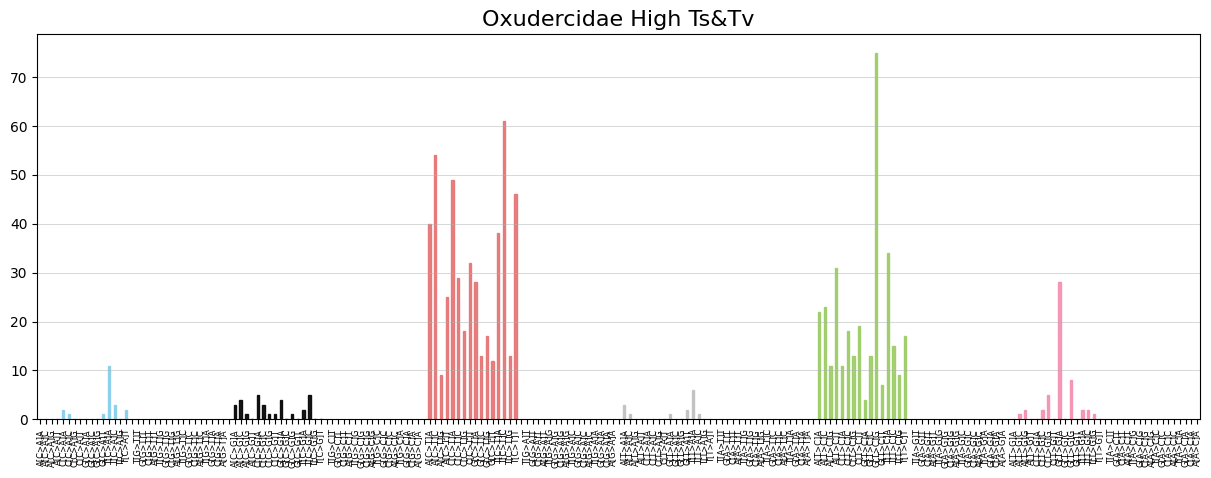

In [23]:
x = high['Oxudercidae__Ts & Tv'].rename('MutSpec')
x.index.name = 'Mut'
x = x.reset_index()
plot_mutspec192(x, title='Oxudercidae High Ts&Tv', figsize=(15, 5));

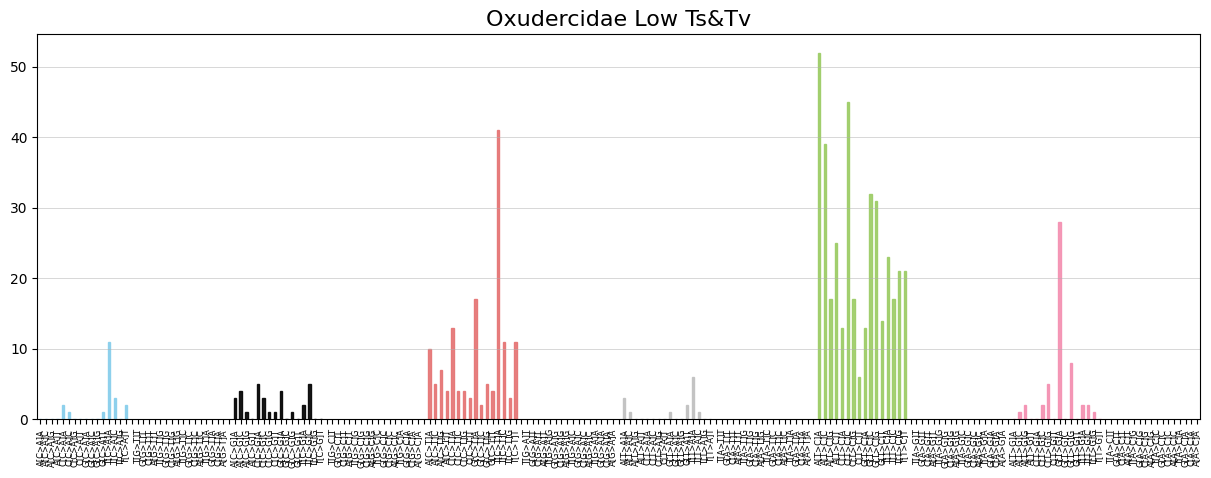

In [24]:
x = low['Oxudercidae__Ts & Tv'].rename('MutSpec')
x.index.name = 'Mut'
x = x.reset_index()
plot_mutspec192(x, title='Oxudercidae Low Ts&Tv', figsize=(15, 5));

## Run SigProfilerAssignment

In [25]:
# Run sigprofiller cosmic_fit func to decompose chordates classes spcectra to COSMIC signatures
# Run on several different spectra types (Low, High, Diff) separately

from SigProfilerAssignment import Analyzer as Analyze

samples_pattern = "./data/SigProfilerAssignment/input/{}_samples.txt"
OUTDIR = "./data/SigProfilerAssignment/output/"
output_pattern = OUTDIR + "{}/"

exclude_signature_subgroups = [
    'Artifact_signatures',
    'Immunosuppressants_signatures',
    'Treatment_signatures',
    'Lymphoid_signatures',
    'Colibactin_signatures',
    'AA_signatures',
]

for label in ["low_Ts", "high_Ts", "high_minus_low_Ts"]:
    samples = samples_pattern.format(label)
    output  = output_pattern.format(label)
    Analyze.cosmic_fit(samples, output, input_type="matrix", context_type="96",
                    cosmic_version=3.3, exome=False,
                    nnls_remove_penalty=0.01, nnls_add_penalty = 0.02,
                    exclude_signature_subgroups=exclude_signature_subgroups, 
                    export_probabilities=False, make_plots=True,
                    sample_reconstruction_plots=False, verbose=False)

The following signatures are excluded: SBS32 SBS11 SBS25 SBS31 SBS32 SBS35 SBS86 SBS87 SBS90 SBS99 SBS22 SBS22a SBS22b SBS88 SBS27 SBS43 SBS45 SBS46 SBS47 SBS48 SBS49 SBS50 SBS51 SBS52 SBS53 SBS54 SBS55 SBS56 SBS57 SBS58 SBS59 SBS60 SBS95 SBS9 SBS84 SBS85
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 8/8 [100%] in 2.9s (2.78/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
The following signatures are excluded: SBS32 SBS11 SBS25 SBS31 SBS32 SBS35 SBS86 SBS87 SBS90 SBS99 SBS22 SBS22a SBS22b SBS88 SBS27 SBS43 SBS45 SBS46 SBS47 SBS48 SBS49 SBS50 SBS51 SBS52 SBS53 SBS54 SBS55 SBS56 SBS57 SBS58 SBS59 SBS60 SBS95 SBS9 SBS84 SBS85
Assigning COSMIC sigs or Signature Database ...... 
|████████████████████████████████████████| 8/8 [100%] in 3.5s (2.26/s) 


 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 
The following signatures are excluded: SBS32 SBS11 SBS25 SBS31 SBS32 S

In [26]:
# make Solution_Stats with assignment quality
d = pd.concat([pd.read_csv(f"{OUTDIR}/{label}/"
        "Assignment_Solution/Solution_Stats/Assignment_Solution_Samples_Stats.txt", sep='\t')\
            .assign(Run=label).set_index(['Run', 'Sample Names']) \
            for label in ["low_Ts", "high_Ts", "high_minus_low_Ts"]])

d.to_csv(f'{OUTDIR}/Solution_Stats.txt', sep='\t')
d.head()

Total Mutations  Cosine Similarity  L1 Norm  \
Run    Sample Names                                                          
low_Ts Eleotridae__Ts only                 375              0.867  213.811   
       Gobiidae__Ts only                   567              0.895  291.320   
       Odontobutidae__Ts only              634              0.889  447.584   
       Oxudercidae__Ts only                530              0.871  313.442   
       Eleotridae__Ts & Tv                 454              0.832  298.562   

                              L1_Norm_%  L2 Norm L2_Norm_%  KL Divergence  \
Run    Sample Names                                                         
low_Ts Eleotridae__Ts only      57.016%   42.566   50.259%        0.33647   
       Gobiidae__Ts only        51.379%   58.161   44.685%        0.27492   
       Odontobutidae__Ts only   70.597%   96.662   45.918%        0.59295   
       Oxudercidae__Ts only      59.14%   59.443   49.581%        0.32827   
       Eleotridae__Ts & Tv      65.763%   48.179   55.573%        0.37381   

                               Correlation  
Run    Sample Names                         
low_Ts Eleotridae__Ts only           0.830  
       Gobiidae__Ts only             0.867  
       Odontobutidae__Ts only        0.877  
       Oxudercidae__Ts only          0.836  
       Eleotridae__Ts & Tv           0.757

## Plot beautiful images and add them to single panel
see modified scpipt [plotActivity.py](./plotActivity.py) from sigProfilerPlotting lib

In [29]:
from pandas import CategoricalDtype
import re

### 1. 根据你自己的 families 列表生成自定义顺序
# families = sorted(cls_spectra_wide.index.tolist())   # 或者你手动指定的顺序
families = ['Gobiidae', 'Eleotridae', 'Odontobutidae','Oxudercidae']  # 示例，替换为你的实际科名列表

# 生成排序用的类别顺序：high-{fam}, low-{fam}, diff-{fam}
set_order = []
for fam in families:
    set_order.extend([f'high-{fam}', f'low-{fam}', f'diff-{fam}'])

cat_type = CategoricalDtype(categories=set_order, ordered=True)

pt_del = r'__Ts & Tv|__Ts'   # 用于清理索引文本

### 2. 动态生成 index_odr 列表
index_odr = []
for fam in families:
    index_odr.append(f'{fam}__Ts only')
for fam in families:
    index_odr.append(f'{fam}__Ts & Tv')

### 3. 读取并合并三个频谱类型的文件
data = []
for label in ["high_Ts", "low_Ts", "high_minus_low_Ts"]:
    d = pd.read_csv(f'{OUTDIR}/{label}/'
                'Assignment_Solution/Activities/Assignment_Solution_Activities.txt', 
                sep='\t', index_col=0).loc[index_odr]
    
    if label == 'low_Ts':
        label_prefix = 'low-'
    elif label == 'high_Ts':
        label_prefix = 'high-'
    elif label == 'high_minus_low_Ts':
        label_prefix = 'diff-'
    
    d.index = label_prefix + d.index.str.replace(' only', '')
    data.append(d)

df_full = pd.concat(data)

# 排序与清理
df_full['Samples_Sort'] = df_full.index.str.replace(pt_del, '', regex=True)
df_full['TsTv'] = df_full.index.str.contains('Tv')
df_full['Samples_Sort'] = df_full['Samples_Sort'].astype(cat_type)
df_full = df_full.sort_values(['Samples_Sort', 'TsTv']).drop(['Samples_Sort', 'TsTv'], axis=1)

# 提取仅转换的谱
df_ts_only = df_full.loc[~df_full.index.str.contains('Tv')]
df_ts_only.index = df_ts_only.index.str.replace('__Ts', '')

# 保存
path_to_total_acivities = f'{OUTDIR}Assignment_Solution_Activities.txt'
df_full.to_csv(path_to_total_acivities, sep='\t')
df_ts_only.to_csv(path_to_total_acivities.replace('.txt', '_Ts.txt'), sep='\t')
df_full

,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,SBS7d,...,SBS39,SBS40,SBS41,SBS42,SBS44,SBS89,SBS91,SBS92,SBS93,SBS94
Samples,,,,,,,,,,,,,,,,,,,,,
high-Gobiidae__Ts,0,76,0,0,636,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
high-Gobiidae__Ts & Tv,0,81,0,0,718,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
low-Gobiidae__Ts,3,31,0,0,40,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
low-Gobiidae__Ts & Tv,0,0,0,0,177,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
diff-Gobiidae__Ts,0,55,0,0,178,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
diff-Gobiidae__Ts & Tv,0,59,0,0,241,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
high-Eleotridae__Ts,0,146,0,0,312,0,0,0,0,0,...,0,0,0,0,373,0,0,0,0,0
high-Eleotridae__Ts & Tv,0,98,0,0,372,0,0,0,0,0,...,0,0,0,575,0,0,0,0,0,0
low-Eleotridae__Ts,1,0,0,0,0,0,0,0,0,40,...,0,0,0,0,0,0,0,0,0,0


In [35]:
# total
from plotActivity import plotActivity

# 保存 PDF
plotActivity(
    path_to_total_acivities, f"{OUTDIR}/total.pdf", 
    bin_size=30, 
    delimiter_step=6, delimiter_size=1,
)

# 保存 PNG
plotActivity(
    path_to_total_acivities, f"{OUTDIR}/total.png", 
    bin_size=30, 
    delimiter_step=6, delimiter_size=1,
)

['#acf2d0', '#63d69e', '#0d4de4', '#9ecef7', '#6cb2f0', '#afa9a9', '#c3c3c3', '#ff0000', '#f0c825', '#00cccc', 'tab:pink', 'tab:orange', 'tab:purple']
['#acf2d0', '#63d69e', '#0d4de4', '#9ecef7', '#6cb2f0', '#afa9a9', '#c3c3c3', '#ff0000', '#f0c825', '#00cccc', 'tab:pink', 'tab:orange', 'tab:purple']


In [31]:
# only Ts
outpath = f"{OUTDIR}/only_Ts.pdf"

plotActivity(
    path_to_total_acivities.replace('.txt', '_Ts.txt'), 
    outpath, 
    bin_size=50,
    delimiter_step=3, delimiter_size=1,
    rename=True, figure_width=4,
)

['#acf2d0', '#63d69e', '#0d4de4', '#9ecef7', '#6cb2f0', '#afa9a9', '#c3c3c3', '#ff0000', '#f0c825', '#00cccc', 'tab:pink', 'tab:orange', 'tab:purple']
